<a href="https://colab.research.google.com/github/shouanrenn/A-B-Testing-Sales-Optimization/blob/main/AB_Testing_Sales_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Persiapan Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
print("--- MEMUAT DATA ---")

data = "https://raw.githubusercontent.com/shouanrenn/A-B-Testing-Sales-Optimization/refs/heads/main/sales.csv"

try:
    df = pd.read_csv(data)
    print(f"Data berhasil dimuat! Dimensi dataset: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("Error: File tidak ditemukan")

--- MEMUAT DATA ---
Data berhasil dimuat! Dimensi dataset: (10000, 7)


,Group,Customer_Segment,Sales_Before,Sales_After,Customer_Satisfaction_Before,Customer_Satisfaction_After,Purchase_Made
0,Control,High Value,240.548359,300.007568,74.684767,NaN,No
1,Treatment,High Value,246.862114,381.337555,100.000000,100.000000,Yes
2,Control,High Value,156.978084,179.330464,98.780735,100.000000,No
3,Control,Medium Value,192.126708,229.278031,49.333766,39.811841,Yes
4,NaN,High Value,229.685623,NaN,83.974852,87.738591,Yes


In [ ]:
print("\nJumlah NaNs per Kolom Sebelum Cleansing:")
print(f"\n{df.isnull().sum()}")


Jumlah NaNs per Kolom Sebelum Cleansing:

Group                           1401
Customer_Segment                1966
Sales_Before                    1522
Sales_After                      767
Customer_Satisfaction_Before    1670
Customer_Satisfaction_After     1640
Purchase_Made                    805
dtype: int64


## **EDA**

In [ ]:
print("--- MENANGANI MISSING VALUES (NaNs) ---")

# A. Imputasi numerik dengan median
num_cols = ['Sales_Before', 'Sales_After', 'Customer_Satisfaction_Before', 'Customer_Satisfaction_After']
for col in num_cols:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# B. Imputasi kategorikal dengan modus
cat_cols = ['Group', 'Customer_Segment', 'Purchase_Made']
for col in cat_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

print("Jumlah NaNs per Kolom Setelah Cleansing:")
print(f"\n{df.isnull().sum()}")

--- MENANGANI MISSING VALUES (NaNs) ---
Jumlah NaNs per Kolom Setelah Cleansing:

Group                           0
Customer_Segment                0
Sales_Before                    0
Sales_After                     0
Customer_Satisfaction_Before    0
Customer_Satisfaction_After     0
Purchase_Made                   0
dtype: int64


## **Uji Statistik A/B Testing**

In [ ]:
print("--- A/B TESTING (ANALISIS KAUSAL) ---")
control_sales = df[df['Group'] == 'Control']['Sales_After']
treatment_sales = df[df['Group'] == 'Treatment']['Sales_After']

print(f"Rata-rata Penjualan - Control   : {control_sales.mean():.2f}")
print(f"Rata-rata Penjualan - Treatment : {treatment_sales.mean():.2f}")

--- A/B TESTING (ANALISIS KAUSAL) ---
Rata-rata Penjualan - Control   : 253.62
Rata-rata Penjualan - Treatment : 314.73


In [ ]:
t_stat, p_value = stats.ttest_ind(control_sales, treatment_sales)
print(f"P-Value dari T-Test: {p_value:.4e}")

P-Value dari T-Test: 0.0000e+00


In [ ]:
if p_value < 0.05:
    print("Kesimpulan Bisnis: Intervensi (Treatment) memberikan peningkatan penjualan yang signifikan secara statistik.")
else:
    print("Kesimpulan Bisnis: Tidak ada perbedaan signifikan. Intervensi mungkin kurang efektif.")

Kesimpulan Bisnis: Intervensi (Treatment) memberikan peningkatan penjualan yang signifikan secara statistik.


In [ ]:
# Feature Enggineering
df_ml = df.copy()

le_group = LabelEncoder()
le_segment = LabelEncoder()

df_ml['Group'] = le_group.fit_transform(df_ml['Group']) # Control: 0, Treatment: 1
df_ml['Customer_Segment'] = le_segment.fit_transform(df_ml['Customer_Segment'])
df_ml['Purchase_Made'] = df_ml['Purchase_Made'].map({'Yes': 1, 'No': 0})

X = df_ml[['Group', 'Customer_Segment', 'Sales_Before', 'Customer_Satisfaction_Before']]
y = df_ml['Purchase_Made']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Melatih model Random Forrest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=7, random_state=42)

In [ ]:
#Evaluasi kinerja model
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(f"\n{classification_report(y_test, y_pred)}")

Classification Report:

              precision    recall  f1-score   support

           0       0.45      0.44      0.44      1345
           1       0.55      0.56      0.56      1655

    accuracy                           0.51      3000
   macro avg       0.50      0.50      0.50      3000
weighted avg       0.51      0.51      0.51      3000



In [ ]:
auc_score = roc_auc_score(y_test, y_prob)
print(f"Skor ROC-AUC: {auc_score:.4f}")

Skor ROC-AUC: 0.5042


## **Visualisasi**

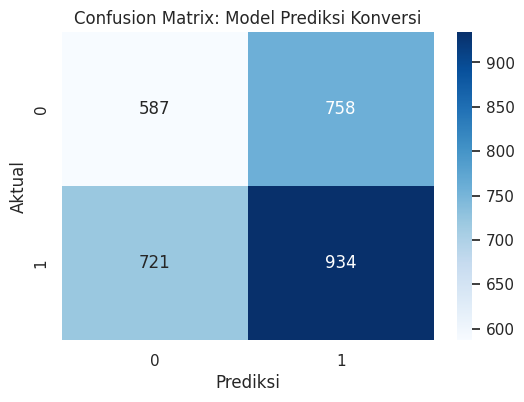

In [ ]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Model Prediksi Konversi')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

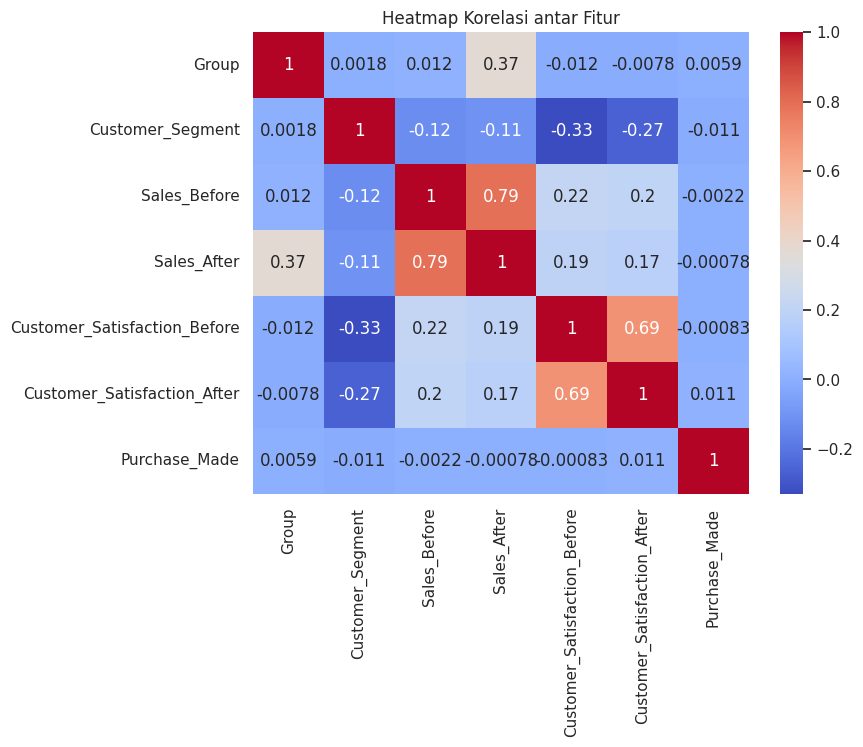

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_ml.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi antar Fitur")
plt.show()